# Numerical Black-Scholes Model Analysis

## The Continuous Problem


## Environment Setup

In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np 
import matplotlib.pyplot as plt 
from scipy import special
from src.engines.black_scholes import bs_solver
from src.utils.convergence import plot_convergence
from src.utils.greeks import gamma, delta, theta

## Numerical Analysis 




## Implementation and Convergence Analysis
### Discretisation



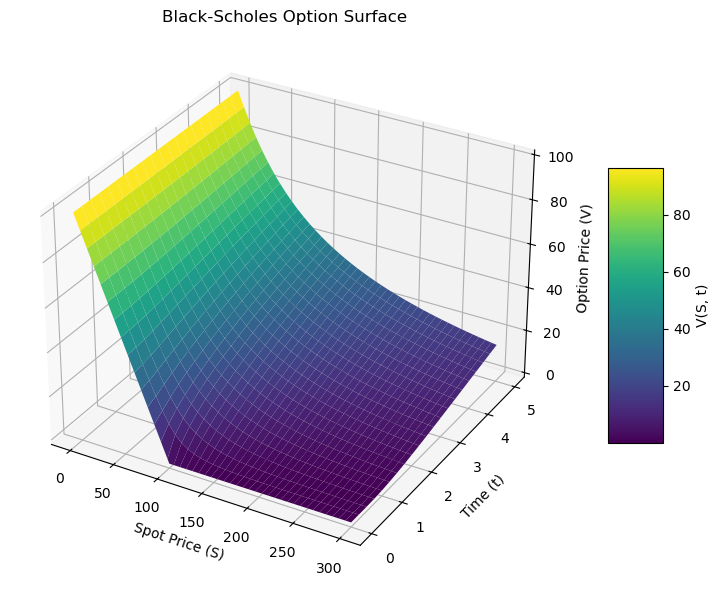

In [4]:
# 3D Surface Plot
K = 100
M = 20
r = 0
vol = 0.5
T = 5
R = 300
f_0 = lambda t: K*np.exp(-r*t)
d_plus = lambda t, s: 1/(vol*np.sqrt(np.maximum(t, 1e-14))) * (np.log(np.maximum(s, 1e-15)/K) + (r + ((vol**2)/2)*np.maximum(t, 1e-14)))
d_minus = lambda t, s: 1/(vol*np.sqrt(np.maximum(t, 1e-14))) * (np.log(s/K) + (r - ((vol**2)/2)*np.maximum(t, 1e-14)))
phi = lambda s: 1/2 * special.erfc(-s/np.sqrt(2))
f_R = lambda t, s: K*np.exp(-r*t)*phi(-d_minus(t, s))-s*phi(-d_plus(t, s))
g = lambda s: np.maximum(K-s, 0)
V, s, t = bs_solver(R, M, f_0, f_R, g, vol, r, T, K)

S_grid, T_grid = np.meshgrid(s, t)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(S_grid, T_grid, V.T, cmap='viridis', edgecolor=None)

ax.set_xlabel('Spot Price (S)')
ax.set_ylabel('Time (t)')
ax.set_zlabel('Option Price (V)')
ax.set_title('Black-Scholes Option Surface')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='V(S, t)')

plt.tight_layout()
plt.show()

### Proof of Convergence


The slope of our log relation is 0.99, proving 0.990576313275957 convergence.


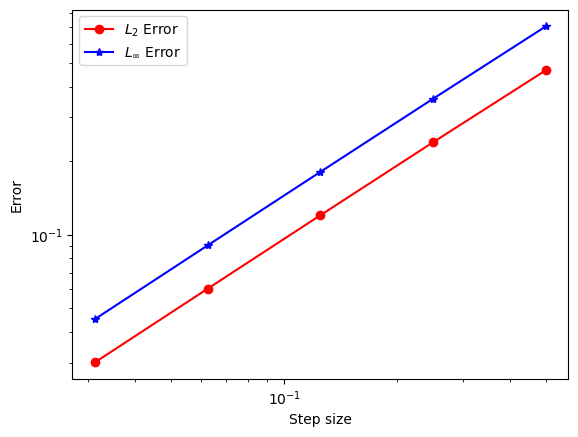

(np.float64(0.990576313275957),
 array([0.5    , 0.25   , 0.125  , 0.0625 , 0.03125]),
 array([0.70504299, 0.35767438, 0.18014298, 0.0903983 , 0.04528074]))

In [6]:
#Temporal Convergence Plot
def time_bs_wrapper(M):
    #Assigning parameters
    K = 100
    r = 0
    vol = 0.5
    T = 5.0
    R = 10000
    f_0 = lambda t: K*np.exp(-r*t)
    d_plus = lambda t, s: 1/(vol*np.sqrt(np.maximum(t, 1e-15))) * (np.log(np.maximum(s, 1e-15)/K) + (r + ((vol**2)/2)*np.maximum(t, 1e-15)))
    d_minus = lambda t, s: 1/(vol*np.sqrt(np.maximum(t, 1e-15))) * (np.log(np.maximum(s, 1e-15)/K) + (r - ((vol**2)/2)*np.maximum(t, 1e-15)))
    phi = lambda s: 1/2 * special.erfc(-s/np.sqrt(2))
    f_R = lambda t, s: K*np.exp(-r*t)*phi(-d_minus(t, s))-s*phi(-d_plus(t, s))
    g = lambda s: np.maximum(K-s, 0)

    #Defining our step size
    dt = T/M
    dx = 1.0/R

    #Asigning our exact and numerical solution
    V_num, s, t = bs_solver(R, M, f_0, f_R, g, vol, r, T, K)
    V_exact = f_R(T, s)

    #Finding Error
    L_inf_error = np.max(np.abs(V_num[:, -1] - V_exact))
    L2_error = np.sqrt(dx*np.sum((V_num[:, -1] - V_exact)**2))
    
    return dt, L2_error, L_inf_error

N_values = [10, 20, 40, 80, 160]

plot_convergence(time_bs_wrapper, N_values)

In [ ]:
#Spatial Convergence Plot
def space_bs_wrapper(R):
    #Assigning parameters
    K = 100
    M = 10000 #Maintaining a large temporal step count to minimise error interference
    r = 0
    vol = 0.5
    T = 5.0
    f_0 = lambda t: K*np.exp(-r*t)
    d_plus = lambda t, s: 1/(vol*np.sqrt(np.maximum(t, 1e-15))) * (np.log(np.maximum(s, 1e-15)/K) + (r + ((vol**2)/2)*np.maximum(t, 1e-15)))
    d_minus = lambda t, s: 1/(vol*np.sqrt(np.maximum(t, 1e-15))) * (np.log(np.maximum(s, 1e-15)/K) + (r - ((vol**2)/2)*np.maximum(t, 1e-15)))
    phi = lambda s: 1/2 * special.erfc(-s/np.sqrt(2))
    f_R = lambda t, s: K*np.exp(-r*t)*phi(-d_minus(t, s))-s*phi(-d_plus(t, s))
    g = lambda s: np.maximum(K-s, 0)
    
    #Defining our step size
    ds = 3*K/R
    
    #Asigning our exact and numerical solution
    V_num, s, t = bs_solver(R, M, f_0, f_R, g, vol, r, T, K)
    V_exact = f_R(T, s)

    #Finding Error
    L_inf_error = np.max(np.abs(V_num[:, -1] - V_exact))
    L2_error = np.sqrt(ds*np.sum((V_num[:, -1] - V_exact)**2))
    
    return ds, L2_error, L_inf_error

N_values = [10, 20, 40, 80, 160]

plot_convergence(space_bs_wrapper, N_values)

## Discussion
TODO:$\newline$
Verification of order of convergence $\newline$
Comparison of Error Norms $\newline$
Temporal vs Spatial Convergence $\newline$
Edge-Cases and Limitations $\newline$

## Summary